In [ ]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph
from langgraph.graph import START, END
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
#from typing import TypedDict, List, Dict, Any,Annotated

from langgraph.checkpoint.memory import MemorySaver
memory= MemorySaver()


from langgraph.types import interrupt,Command

/home/anjucv/.cache/pypoetry/virtualenvs/rag-task1-_QzYQtjV-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import numpy as np

In [3]:
from langchain_openai import ChatOpenAI
from langchain.tools import tool
#from langchain.agents import initialize_agent, AgentType

In [4]:
from dotenv import load_dotenv

load_dotenv()

True

In [5]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4.1-mini")

In [6]:
llm

ChatOpenAI(profile={'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x71c100caea80>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x71c100ce0dd0>, root_client=<openai.OpenAI object at 0x71c10132f170>, root_async_client=<openai.AsyncOpenAI object at 0x71c10132f5f0>, model_name='gpt-4.1-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [7]:
#llm.invoke('who is president of india')

In [8]:
# create tools

In [9]:
@tool
def load_stock_data(file_path: str) -> str:
    """
    Load stock data from CSV and return closing prices.
    """
    df = pd.read_csv(file_path)
    return str(df["close"].tolist())


@tool
def calculate_moving_average(prices: str) -> str:
    """
    Calculate moving average from price list.
    Input must be a list string.
    """
    import ast
    prices = ast.literal_eval(prices)
    ma = pd.Series(prices).rolling(3).mean().tolist()
    return str(ma)


@tool
def trend_strength(prices: str) -> str:
    """
    Calculate trend strength using price volatility and slope.

    Returns:
    - STRONG
    - MODERATE
    - WEAK
    """
    import ast
    import numpy as np

    prices = ast.literal_eval(prices)

    # slope (trend direction strength)
    x = np.arange(len(prices))
    slope = np.polyfit(x, prices, 1)[0]

    # volatility
    volatility = np.std(prices)

    if abs(slope) > 1 and volatility < 2:
        return "STRONG"
    elif abs(slope) > 0.3:
        return "MODERATE"
    else:
        return "WEAK"
    
@tool
def detect_spike(prices: str) -> str:
    """
    Detect sudden spikes or drops in price.

    Returns:
    - SPIKE UP
    - SPIKE DOWN
    - NO SPIKE
    """
    import ast

    prices = ast.literal_eval(prices)

    for i in range(1, len(prices)):
        change = (prices[i] - prices[i-1]) / prices[i-1]

        if change > 0.05:
            return "SPIKE UP"
        elif change < -0.05:
            return "SPIKE DOWN"

    return "NO SPIKE"

In [10]:


# result = detect_spike.invoke({
#     "prices": "[100, 102, 70, 106, 80]"
# })

# print(result)

In [11]:
# define state

In [12]:
from typing import TypedDict, List, Literal
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    messages: List[BaseMessage]
    next_agent: str
    task_complete: bool
    file_paths: dict   

In [13]:
# tool exicution node

In [14]:
from langgraph.prebuilt import ToolNode

# Register your tools here
tools = [
    load_stock_data,
    calculate_moving_average,
    trend_strength,
    detect_spike
]

tool_node = ToolNode(tools)

def execute_tools(state: AgentState):
    """
    Executes tool calls if present in last message.
    """
    last_message = state["messages"][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return tool_node.invoke(state)

    return state

In [15]:
# data loader agents

In [16]:
from langchain_core.messages import SystemMessage

def data_loader_agent(state: AgentState):
    file_paths = state.get("file_paths", {})

    content = "Load stock data for:\n"
    for name, path in file_paths.items():
        content += f"{name}: {path}\n"

    system_msg = SystemMessage(
        content="Use load_stock_data tool for each file."
    )

    llm_with_tools = llm.bind_tools([load_stock_data])

    response = llm_with_tools.invoke(
        [system_msg, HumanMessage(content=content)]
    )
    print(response)

    return {
        "messages": [response],
        "next_agent": "analyst"
    }

In [17]:
# analyst agent

In [18]:
from langchain_core.messages import  AIMessage

In [ ]:
def analyst_agent(state: AgentState):

    print("\n--- DEBUG analyst input ---")
    for m in state["messages"]:
        print(m.type, ":", m.content)
    print("---------------------------\n")

    # Extract only raw price lists
    price_data = []

    for m in state["messages"]:
        if m.type == "tool":
            content = m.content.strip()
            if content.startswith("[") and content.endswith("]"):
                price_data.append(content)

    results = []

    #ll 3 tools for each stock
    for data in price_data:
        ma = calculate_moving_average.invoke({"prices": data})
        trend = trend_strength.invoke({"prices": data})
        spike = detect_spike.invoke({"prices": data})

        results.append(
            f"Stock:\n"
            f"Prices: {data}\n"
            f"Moving Avg: {ma}\n"
            f"Trend: {trend}\n"
            f"Spike: {spike}\n"
        )

    final_analysis = "\n\n".join(results)

    return {
        "messages": [AIMessage(content=final_analysis)],
        "next_agent": "comparator"
    }

In [20]:
# comparator agent

In [ ]:
#from langchain_core.messages import HumanMessage

def comparator_agent(state: AgentState):
    """
    Compares multiple stocks
    """

    print("\n--- DEBUG comparator input ---")
    for m in state["messages"]:
        print(m.type, ":", m.content)
    print("--------------------------------\n")

    #Extract only AI/Human messages
    clean_messages = [
        m for m in state["messages"]
        if m.type in ("human", "ai")
    ]

    system_msg = SystemMessage(
        content=(
            "You are a stock comparison expert.\n"
            "Compare multiple stocks based on:\n"
            "- Trend\n"
            "- Stability\n"
            "- Spike behavior\n"
            "Give a clear comparison."
        )
    )

    response = llm.invoke([system_msg] + clean_messages)
    print(response)

    return {
        "messages": [response],
        "next_agent": "summarizer"
    }

In [22]:
# summarizer agent

In [23]:
def summarizer_agent(state: AgentState):
    """
    Generates final summary
    """
    messages = state["messages"]

    system_msg = SystemMessage(
        content="You are a financial report writer. Summarize the analysis clearly."
    )

    response = llm.invoke([system_msg] + messages)

    return {
        "messages": [response],
        "next_agent": "end",
        "task_complete": True
    }

In [24]:
builder = StateGraph(AgentState)

builder.add_node("data_loader", data_loader_agent)
builder.add_node("analyst", analyst_agent)
builder.add_node("comparator", comparator_agent)
builder.add_node("summarizer", summarizer_agent)
builder.add_node("tools", tool_node)

builder.add_edge(START, "data_loader")

builder.add_conditional_edges("data_loader", tools_condition)
#builder.add_conditional_edges("analyst", tools_condition)

builder.add_edge("tools", "analyst")
builder.add_edge("analyst", "comparator")
builder.add_edge("comparator","summarizer")
builder.add_edge("summarizer", END)

graph = builder.compile(checkpointer=memory)

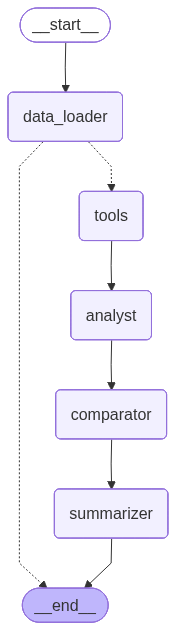

In [25]:
graph

In [29]:
result = graph.invoke(
    {
        "file_paths": {
            "HDFC": "stock_files/hdfc.csv",
            "INFY": "stock_files/infy.csv"
        }
    },
    config={"configurable": {"thread_id": "test-1"}}
)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 83, 'total_tokens': 141, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_62bab17333', 'id': 'chatcmpl-DMralIZZe4b1aIjcu8gfECnKSjXNF', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d1f00-16f6-7631-8785-a23d3aff9ae1-0' tool_calls=[{'name': 'load_stock_data', 'args': {'file_path': 'stock_files/hdfc.csv'}, 'id': 'call_ZeRvDr27kmmWzXu87Tzr86z2', 'type': 'tool_call'}, {'name': 'load_stock_data', 'args': {'file_path': 'stock_files/infy.csv'}, 'id': 'call_RiUY0snOxVpcckZ26UotqqAC', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 83, 'output_tokens': 58

In [30]:
print(result['messages'][0].content)

The two stocks both exhibit moderate upward trends over the analyzed period. Stock 1 shows a gradual increase from approximately 1610 to around 1650, indicating steady growth with moderate stability and no sudden price spikes. Stock 2 maintains prices mostly in the range of 1510 to 1520, reflecting a relatively stable performance with minor fluctuations and no sharp jumps. Overall, Stock 1 demonstrates slightly stronger upward momentum, while Stock 2 offers steadier but less pronounced growth; neither stock displays any spike behavior during this period.
